In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [10]:
tourism_df = pd.read_csv('../data/cleaned/tourism_data_clean.csv')
hotels_df = pd.read_csv('../data/cleaned/hotels_data_clean.csv')
flights_df = pd.read_csv('../data/cleaned/flights_clean.csv')
flight_cost_clean_df = pd.read_csv('../data/cleaned/flight_cost_clean.csv')

## EDA

In [11]:
## basic information

print("Shape :", tourism_df.shape)
print("\nColumns:")
print(tourism_df.columns)

tourism_df.head()

Shape : (92, 10)

Columns:
Index(['Destination', 'State', 'Category', 'Best Season', 'Average Budget',
       'Recommended Trip Duration', 'Nearest Airport', 'Popularity',
       'Family Friendly', 'Adventure Score'],
      dtype='str')


,Destination,State,Category,Best Season,Average Budget,Recommended Trip Duration,Nearest Airport,Popularity,Family Friendly,Adventure Score
0,Goa,Goa,Beach,Nov-Feb,30000,4,Goa Airport,High,Yes,6
1,Ladakh (Leh),Ladakh,Mountain,Mar-Jun,35000,5,Ladakh Airport,High,Yes,9
2,Jaipur,Rajasthan,Heritage,Oct-Mar,22000,3,Jaipur Airport,High,Yes,3
3,Varanasi (Kashi),Uttar Pradesh,Spiritual,Oct-Mar,18000,2,Varanasi Airport,High,Yes,2
4,Agra,Uttar Pradesh,Heritage,Oct-Mar,22000,3,Agra Airport,High,Yes,3


In [12]:
## Numerical and Categorical columns

numerical_columns = tourism_df.select_dtypes(include=np.number).columns

categorical_columns = tourism_df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Average Budget', 'Recommended Trip Duration', 'Adventure Score'], dtype='str')

Categorical Columns:
Index(['Destination', 'State', 'Category', 'Best Season', 'Nearest Airport',
       'Popularity', 'Family Friendly'],
      dtype='str')


In [13]:
##  Statistical Summary
tourism_df.describe()

,Average Budget,Recommended Trip Duration,Adventure Score
count,92.000000,92.000000,92.000000
mean,28043.478261,3.717391,6.369565
std,5862.739568,1.041196,2.421140
min,18000.000000,2.000000,2.000000
25%,25000.000000,3.000000,5.000000
50%,27500.000000,3.500000,7.000000
75%,35000.000000,5.000000,9.000000
max,35000.000000,5.000000,9.000000


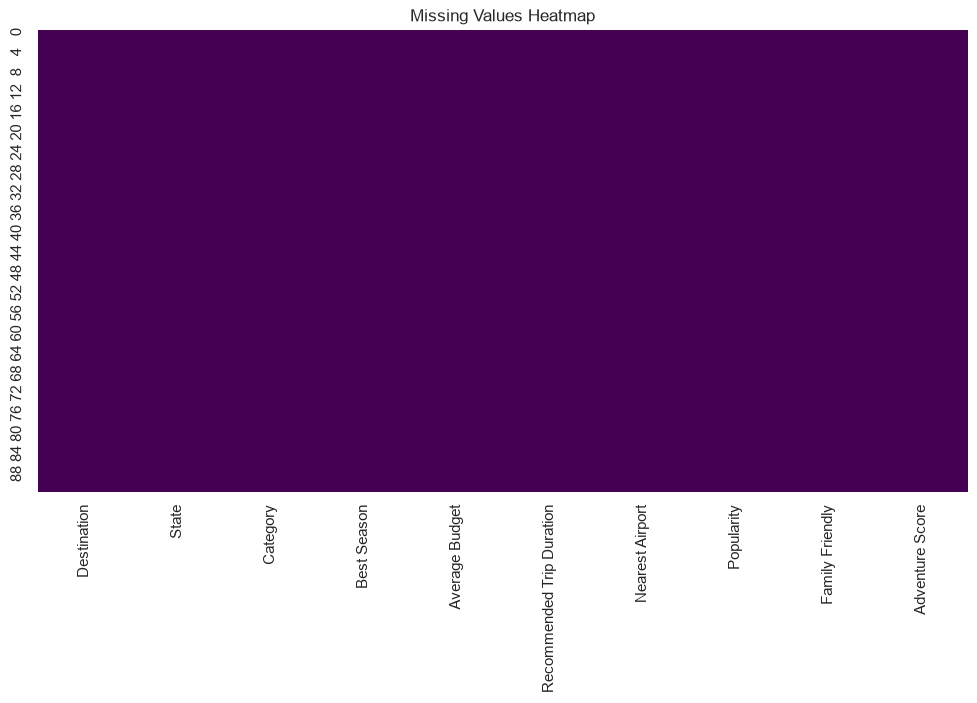

In [15]:
## Missing values HeatMap

plt.figure(figsize=(12,6))

sns.heatmap(
    tourism_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [24]:
tourism_df['Category'].value_counts()

Category
Hill Station      16
Spiritual         10
Heritage           9
Nature             8
Island             7
Beach              6
Wildlife           6
Mountain           5
Adventure          5
Coastal            3
Desert             3
Bird Sanctuary     3
Valley             2
Waterfall          2
Snow               2
Backwaters         1
Lake               1
Cultural           1
Rainforest         1
Rural              1
Name: count, dtype: int64

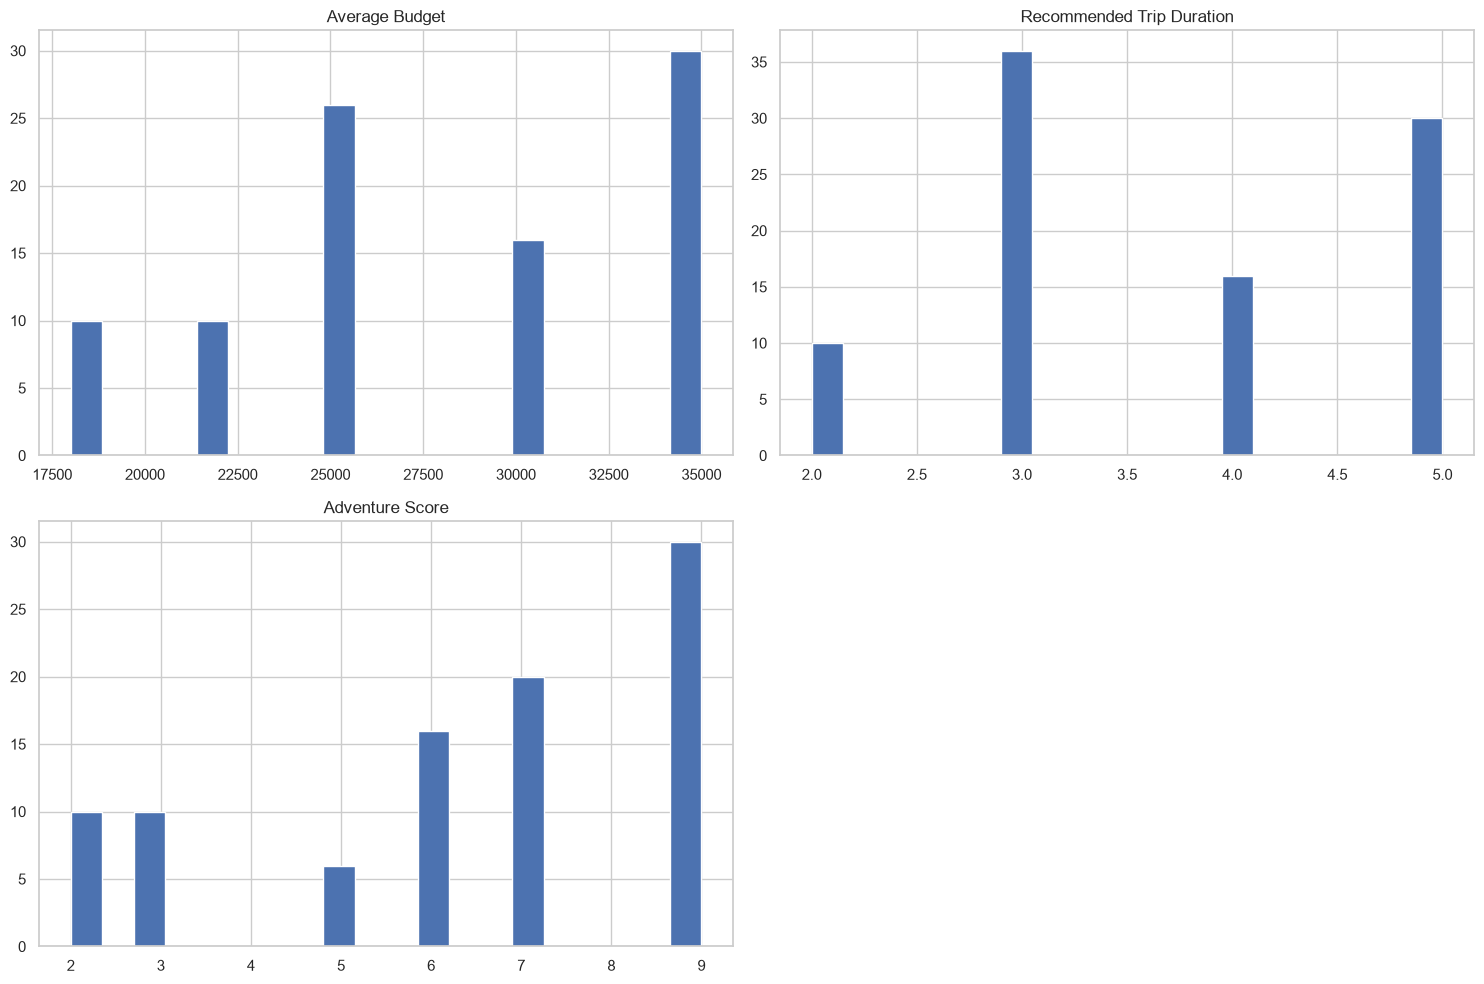

In [ ]:
## Numerical Feature Distribution
tourism_df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

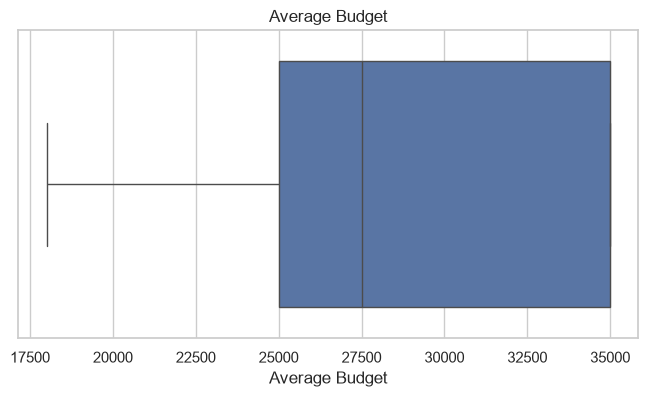

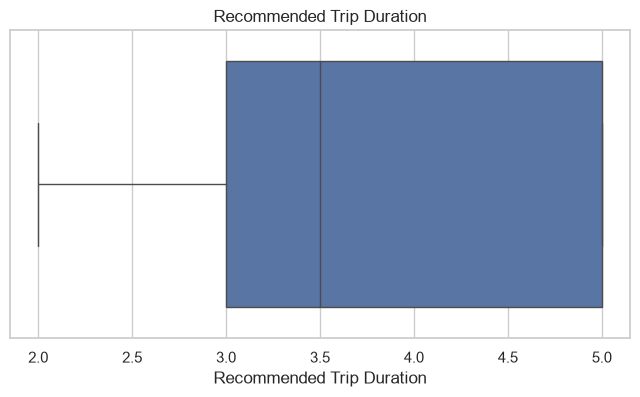

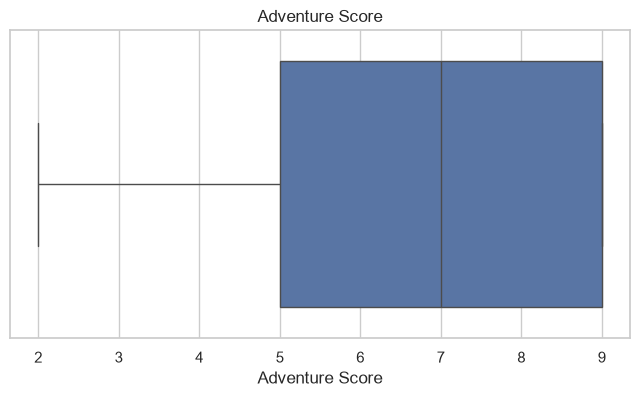

In [17]:
## Boxplots (Outlier Detection)
numeric_cols = tourism_df.select_dtypes(include=np.number).columns

for column in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=tourism_df[column])

    plt.title(column)

    plt.show()

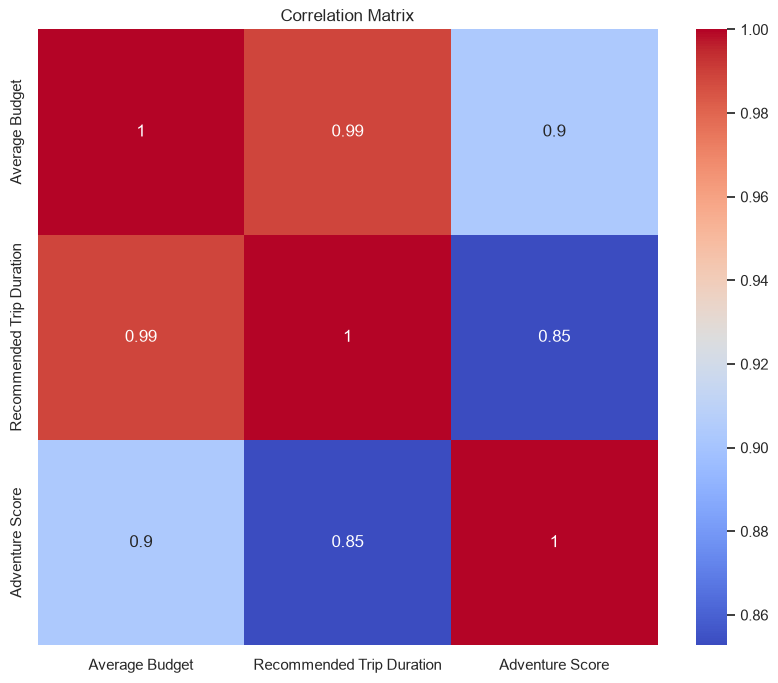

In [19]:
## Correlation Matrix
numeric_df = tourism_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

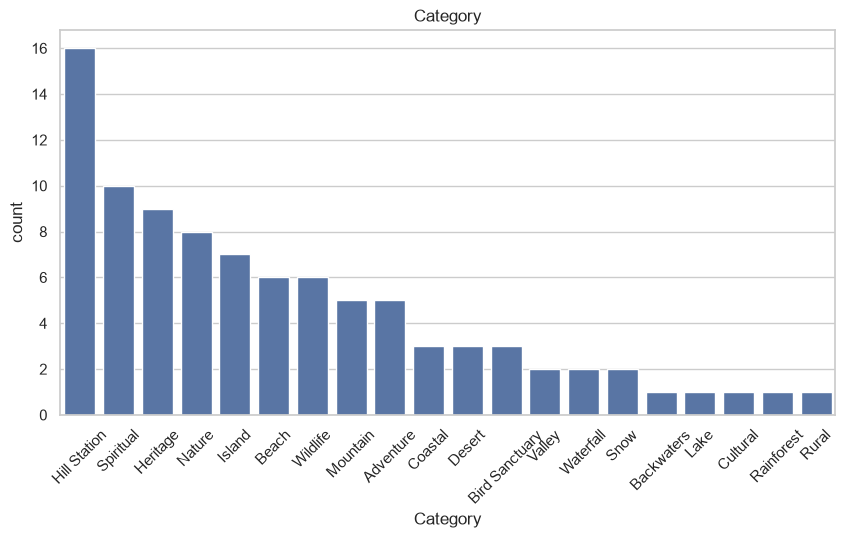

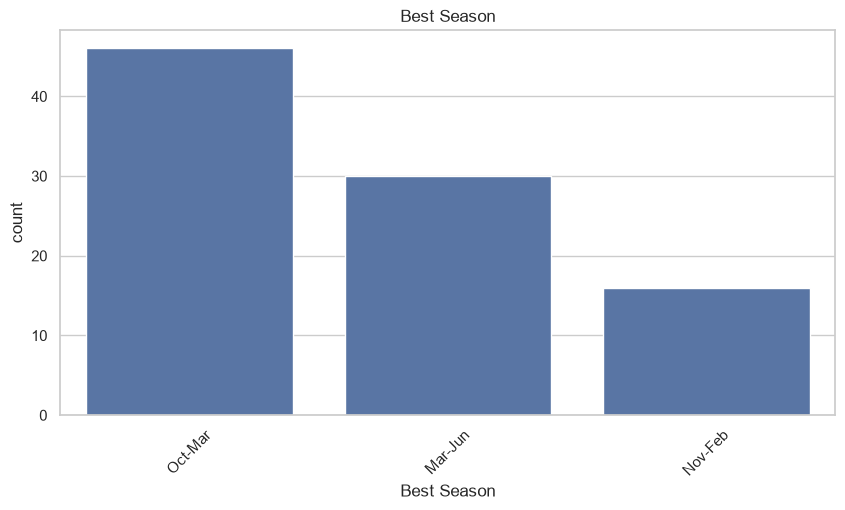

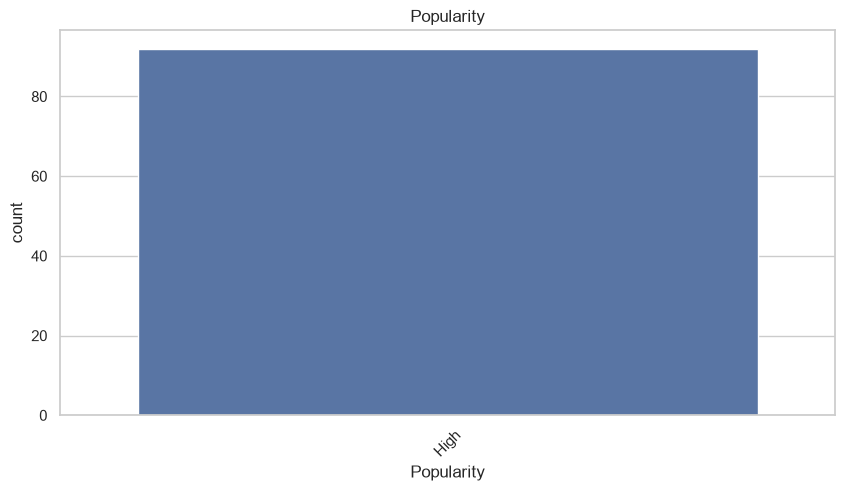

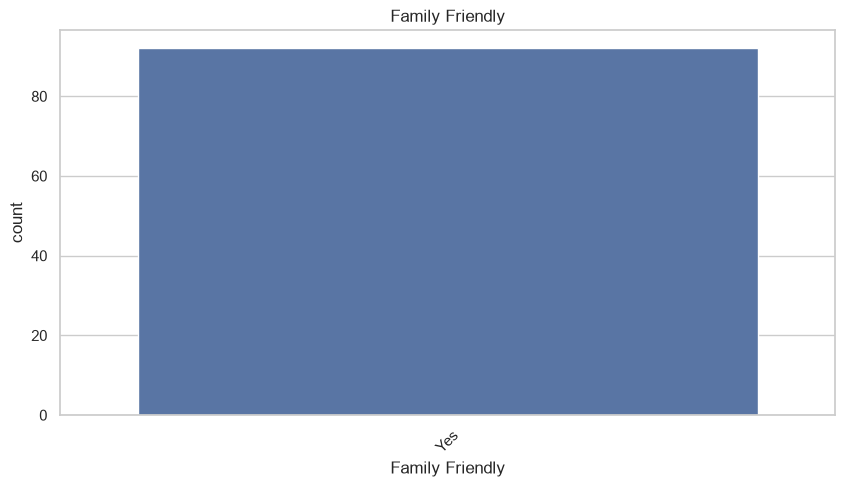

In [20]:
## Count Plot for Categorical Columns

for column in tourism_df.select_dtypes(include="object").columns:

    if tourism_df[column].nunique() <= 20:

        plt.figure(figsize=(10,5))

        sns.countplot(
            data=tourism_df,
            x=column,
            order=tourism_df[column].value_counts().index
        )

        plt.xticks(rotation=45)

        plt.title(column)

        plt.show()